### 0 - Import required packages

In [27]:
# basics
import os
import numpy as np
import pprint as pp

# pandas is used to read/process data
import pandas as pd
from scipy.stats import linregress

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

### 1 - Import Dataset

In [4]:
# load data locally

DATA_FILE = "Data/20251120_Silicon.csv"
df = pd.read_csv(DATA_FILE)
print(f"✅ Loaded data from {DATA_FILE}, shape = {df.shape}")

✅ Loaded data from Data/20251120_Silicon.csv, shape = (210, 17)


Look at the first rows to see if everythings seems reasonable

In [5]:
df.head()

,time_s,water_b1_ml_min,water_b2_ml_min,water_b3_ml_min,water_a1_ml_min,si350_t1_ml_min,si350_t2_ml_min,si350_t3_ml_min,si1000_t1_ml_min,si1000_t2_ml_min,si1000_t3_ml_min,si5000_t1_ml_min,si5000_t2_ml_min,si5000_t3_ml_min,si12500_t1_ml_min,si12500_t2_ml_min,si12500_t3_ml_min
0,0.007,0.4326,-0.1444,0.2212,0.0666,0.0702,-0.0776,-0.0870,0.0870,0.1034,0.1002,0.0720,-0.0218,0.0454,-0.0950,0.0458,0.0700
1,0.507,0.4514,-0.1550,0.1898,0.0614,0.0654,-0.0306,-0.0708,0.0824,0.1026,0.0900,0.0712,-0.0052,0.0252,-0.0820,0.0350,0.0630
2,1.007,0.4106,0.0296,0.1964,0.0544,0.0588,0.0298,-0.0406,0.0758,0.1118,0.0822,0.0678,0.0150,-0.0200,-0.0674,0.0318,0.0794
3,1.507,0.4992,0.2690,0.1956,0.0536,0.0578,0.0634,0.0224,0.0726,0.1160,0.0778,0.0604,0.0354,-0.0376,-0.0536,0.0328,0.0802
4,2.007,0.3524,0.3612,0.1364,0.0524,-0.0926,0.0988,0.0638,0.0702,0.1162,0.0736,0.0134,0.0494,-0.0394,-0.0396,0.0384,0.0820


## 2 - Visualize

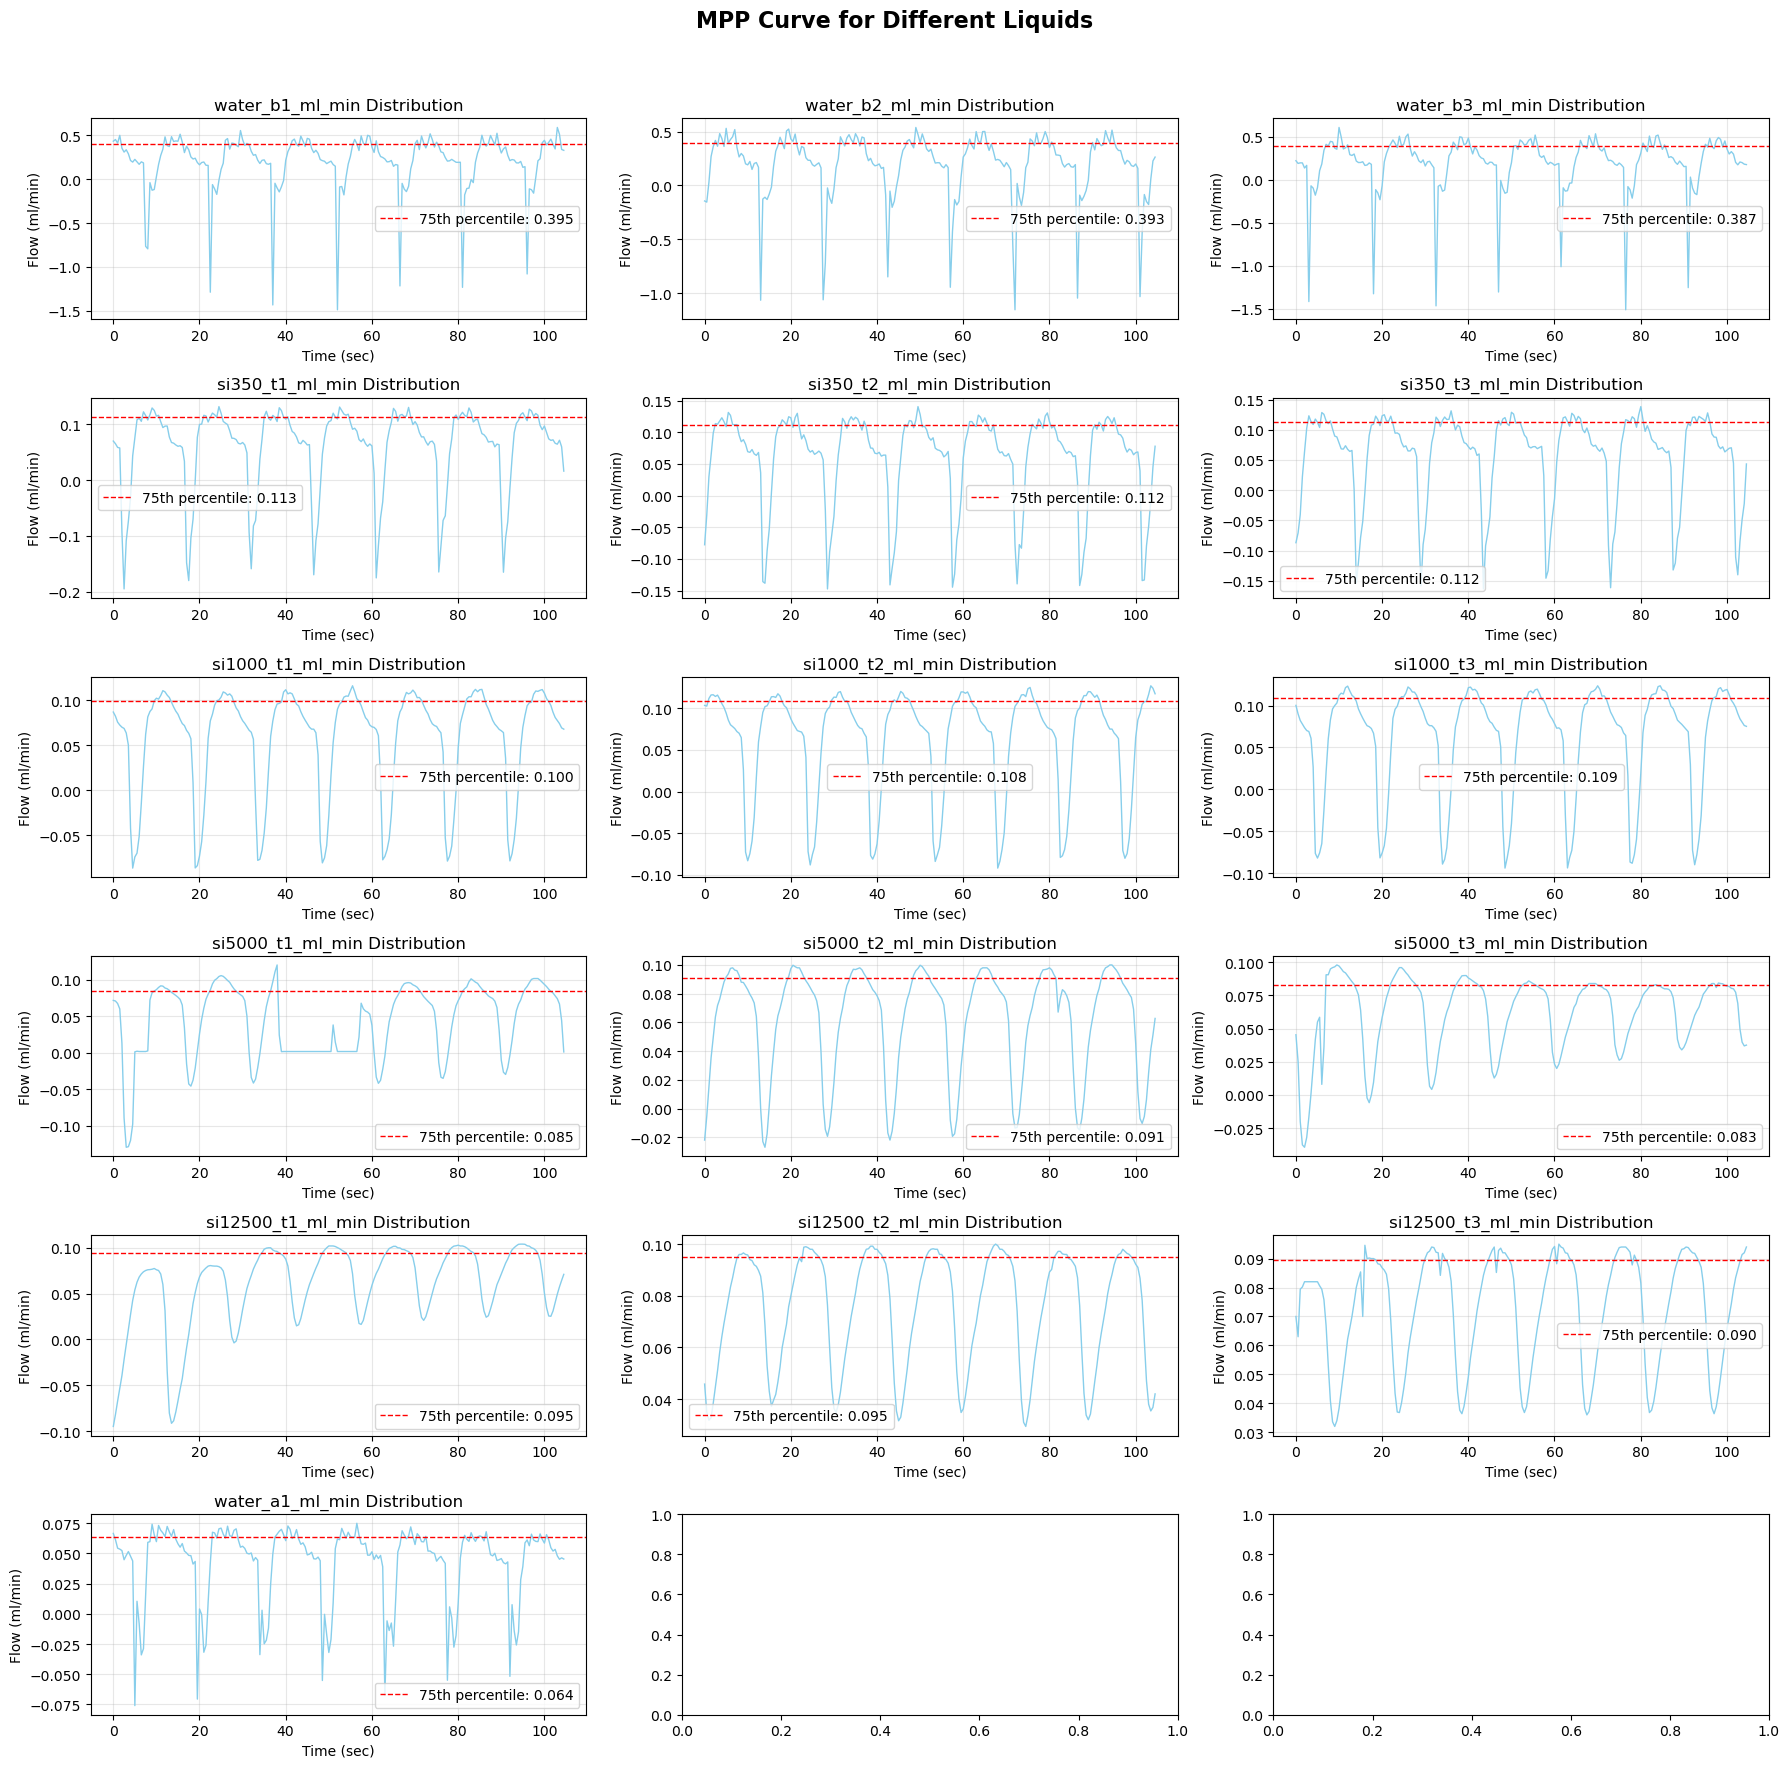

In [15]:
# Create visualizations for molecular descriptors
fig, axes = plt.subplots(6, 3, figsize=(18, 18))
fig.suptitle('MPP Curve for Different Liquids', fontsize=16, fontweight='bold')

# Define descriptors to plot
descriptors_to_plot = [
    'water_b1_ml_min', 'water_b2_ml_min', 'water_b3_ml_min',
    'si350_t1_ml_min', 'si350_t2_ml_min', 'si350_t3_ml_min',
    'si1000_t1_ml_min', 'si1000_t2_ml_min', 'si1000_t3_ml_min',
    'si5000_t1_ml_min', 'si5000_t2_ml_min', 'si5000_t3_ml_min',
    'si12500_t1_ml_min', 'si12500_t2_ml_min', 'si12500_t3_ml_min',
    'water_a1_ml_min'
]

for i, descriptor in enumerate(descriptors_to_plot):
    row = i // 3
    col = i % 3

    # Line plot (time vs descriptor)
    sns.lineplot(
        data=df, x='time_s', y=descriptor,
        ax=axes[row, col], color="skyblue", linewidth=1, errorbar=None
    )

    # # Filter only the first 50 seconds
    # subset = df[df['time_s'] <= 50]

    # Compute 75th percentile for this subset
    q75 = df[descriptor].quantile(0.75)

    # Add straight horizontal line at 75% value
    axes[row, col].axhline(y=q75, color='red', linestyle='--', linewidth=1,
                           label=f'75th percentile: {q75:.3f}')

    # Titles and labels
    axes[row, col].set_title(f'{descriptor} Distribution')
    axes[row, col].set_xlabel('Time (sec)')
    axes[row, col].set_ylabel('Flow (ml/min)')
    axes[row, col].grid(True, alpha=0.3)
    #axes[row, col].set_ylim(-0.3, 0.2)
    axes[row, col].legend()


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 3 - Cycle Detection

In [21]:
# Extract time
time = df['time_s'].values

# Define flow columns in specific order
flow_columns = [
    'water_b1_ml_min', 'water_b2_ml_min', 'water_b3_ml_min',
    'si350_t1_ml_min', 'si350_t2_ml_min', 'si350_t3_ml_min',
    'si1000_t1_ml_min', 'si1000_t2_ml_min', 'si1000_t3_ml_min',
    'si5000_t1_ml_min', 'si5000_t2_ml_min', 'si5000_t3_ml_min',
    'si12500_t1_ml_min', 'si12500_t2_ml_min', 'si12500_t3_ml_min',
    'water_a1_ml_min'
]

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(f"Total time points: {len(time)}")
print(f"Time range: {time[0]:.1f} - {time[-1]:.1f} seconds")
print(f"Flow columns to analyze: {len(flow_columns)}")
for i, col in enumerate(flow_columns, 1):
    print(f"  {i}. {col}")
print()

def filter_peaks_troughs(time, flow, peaks, troughs, min_distance=2.0):
    """
    Filter peaks and troughs based on:
    1. Percentile thresholds (peaks > 75th, troughs < 25th)
    2. Minimum time distance between consecutive peaks/troughs
    """
    # Calculate percentile thresholds
    valid_flow = flow[~np.isnan(flow)]
    if len(valid_flow) == 0:
        return np.array([]), np.array([]), np.nan, np.nan
    
    peak_threshold = np.percentile(valid_flow, 75)
    trough_threshold = np.percentile(valid_flow, 10)
    
    # Filter peaks above 75th percentile
    valid_peaks = []
    for p in peaks:
        if not np.isnan(flow[p]) and flow[p] >= peak_threshold:
            # Check distance from previously added peaks
            if len(valid_peaks) == 0 or (time[p] - time[valid_peaks[-1]]) >= min_distance:
                valid_peaks.append(p)
    
    # Filter troughs below 10th percentile
    valid_troughs = []
    for t in troughs:
        if not np.isnan(flow[t]) and flow[t] <= trough_threshold:
            # Check distance from previously added troughs
            if len(valid_troughs) == 0 or (time[t] - time[valid_troughs[-1]]) >= min_distance:
                valid_troughs.append(t)
    
    return np.array(valid_peaks), np.array(valid_troughs), peak_threshold, trough_threshold

def detect_cycles(time, flow, peaks, troughs):
    """
    Detect cycles with pattern: trough -> peak -> trough
    Handle consecutive troughs: first trough = start, first trough after peak = end
    Handle consecutive peaks: continue through them
    """
    if len(peaks) == 0 or len(troughs) == 0:
        return []
    
    # Combine and sort all critical points
    all_points = []
    for p in peaks:
        all_points.append(('peak', p, time[p], flow[p]))
    for t in troughs:
        all_points.append(('trough', t, time[t], flow[t]))
    
    all_points.sort(key=lambda x: x[1])  # Sort by index
    
    cycles = []
    i = 0
    
    while i < len(all_points):
        # Look for a trough to start a cycle
        if all_points[i][0] == 'trough':
            cycle_start_idx = all_points[i][1]
            cycle_start_time = all_points[i][2]
            
            # Skip consecutive troughs, keep the first one as start
            j = i + 1
            while j < len(all_points) and all_points[j][0] == 'trough':
                j += 1
            
            # Now we should find peak(s)
            if j < len(all_points) and all_points[j][0] == 'peak':
                # Continue through consecutive peaks
                while j < len(all_points) and all_points[j][0] == 'peak':
                    j += 1
                
                # Now look for the next trough (end of cycle)
                if j < len(all_points) and all_points[j][0] == 'trough':
                    cycle_end_idx = all_points[j][1]
                    cycle_end_time = all_points[j][2]
                    
                    cycles.append({
                        'start_time': cycle_start_time,
                        'end_time': cycle_end_time,
                        'duration': cycle_end_time - cycle_start_time,
                        'start_idx': cycle_start_idx,
                        'end_idx': cycle_end_idx
                    })
                    
                    # Move to this trough to potentially start next cycle
                    i = j
                    continue
        
        i += 1
    
    return cycles


DATASET INFORMATION
Total time points: 210
Time range: 0.0 - 104.5 seconds
Flow columns to analyze: 16
  1. water_b1_ml_min
  2. water_b2_ml_min
  3. water_b3_ml_min
  4. si350_t1_ml_min
  5. si350_t2_ml_min
  6. si350_t3_ml_min
  7. si1000_t1_ml_min
  8. si1000_t2_ml_min
  9. si1000_t3_ml_min
  10. si5000_t1_ml_min
  11. si5000_t2_ml_min
  12. si5000_t3_ml_min
  13. si12500_t1_ml_min
  14. si12500_t2_ml_min
  15. si12500_t3_ml_min
  16. water_a1_ml_min



ANALYZING: water_b1_ml_min

Initial detection:
  Raw peaks found: 48
  Raw troughs found: 47

After filtering (75th/10th percentile + min distance 2.0s):
  Peak threshold (75th percentile): 0.3948
  Trough threshold (10th percentile): -0.1028
  Valid peaks: 26
    Times: [  0.507   1.507  12.009  13.509  15.509  26.513  27.513  29.514  31.014
  42.014  43.514  45.014  56.014  57.514  59.014  61.014  70.518  71.518
  73.518  75.018  85.527  87.527  89.027 100.027 101.527 103.027]
    Values: [0.4514 0.4992 0.482  0.4842 0.5118 0.4624 0.4108 0.554  0.4074 0.4564
 0.4902 0.4646 0.4522 0.493  0.4996 0.4372 0.4424 0.4914 0.5164 0.4212
 0.5004 0.4972 0.5228 0.442  0.456  0.589 ]
  Valid troughs: 13
    Times: [ 8.007  9.007 22.513 24.013 37.014 38.514 52.014 53.514 66.515 68.015
 81.027 96.027 97.527]
    Values: [-0.7944 -0.1264 -1.2886 -0.1736 -1.4338 -0.1454 -1.4888 -0.1796 -1.217
 -0.142  -1.2332 -1.0808 -0.1598]

──────────────────────────────────────────────────────────────────────────

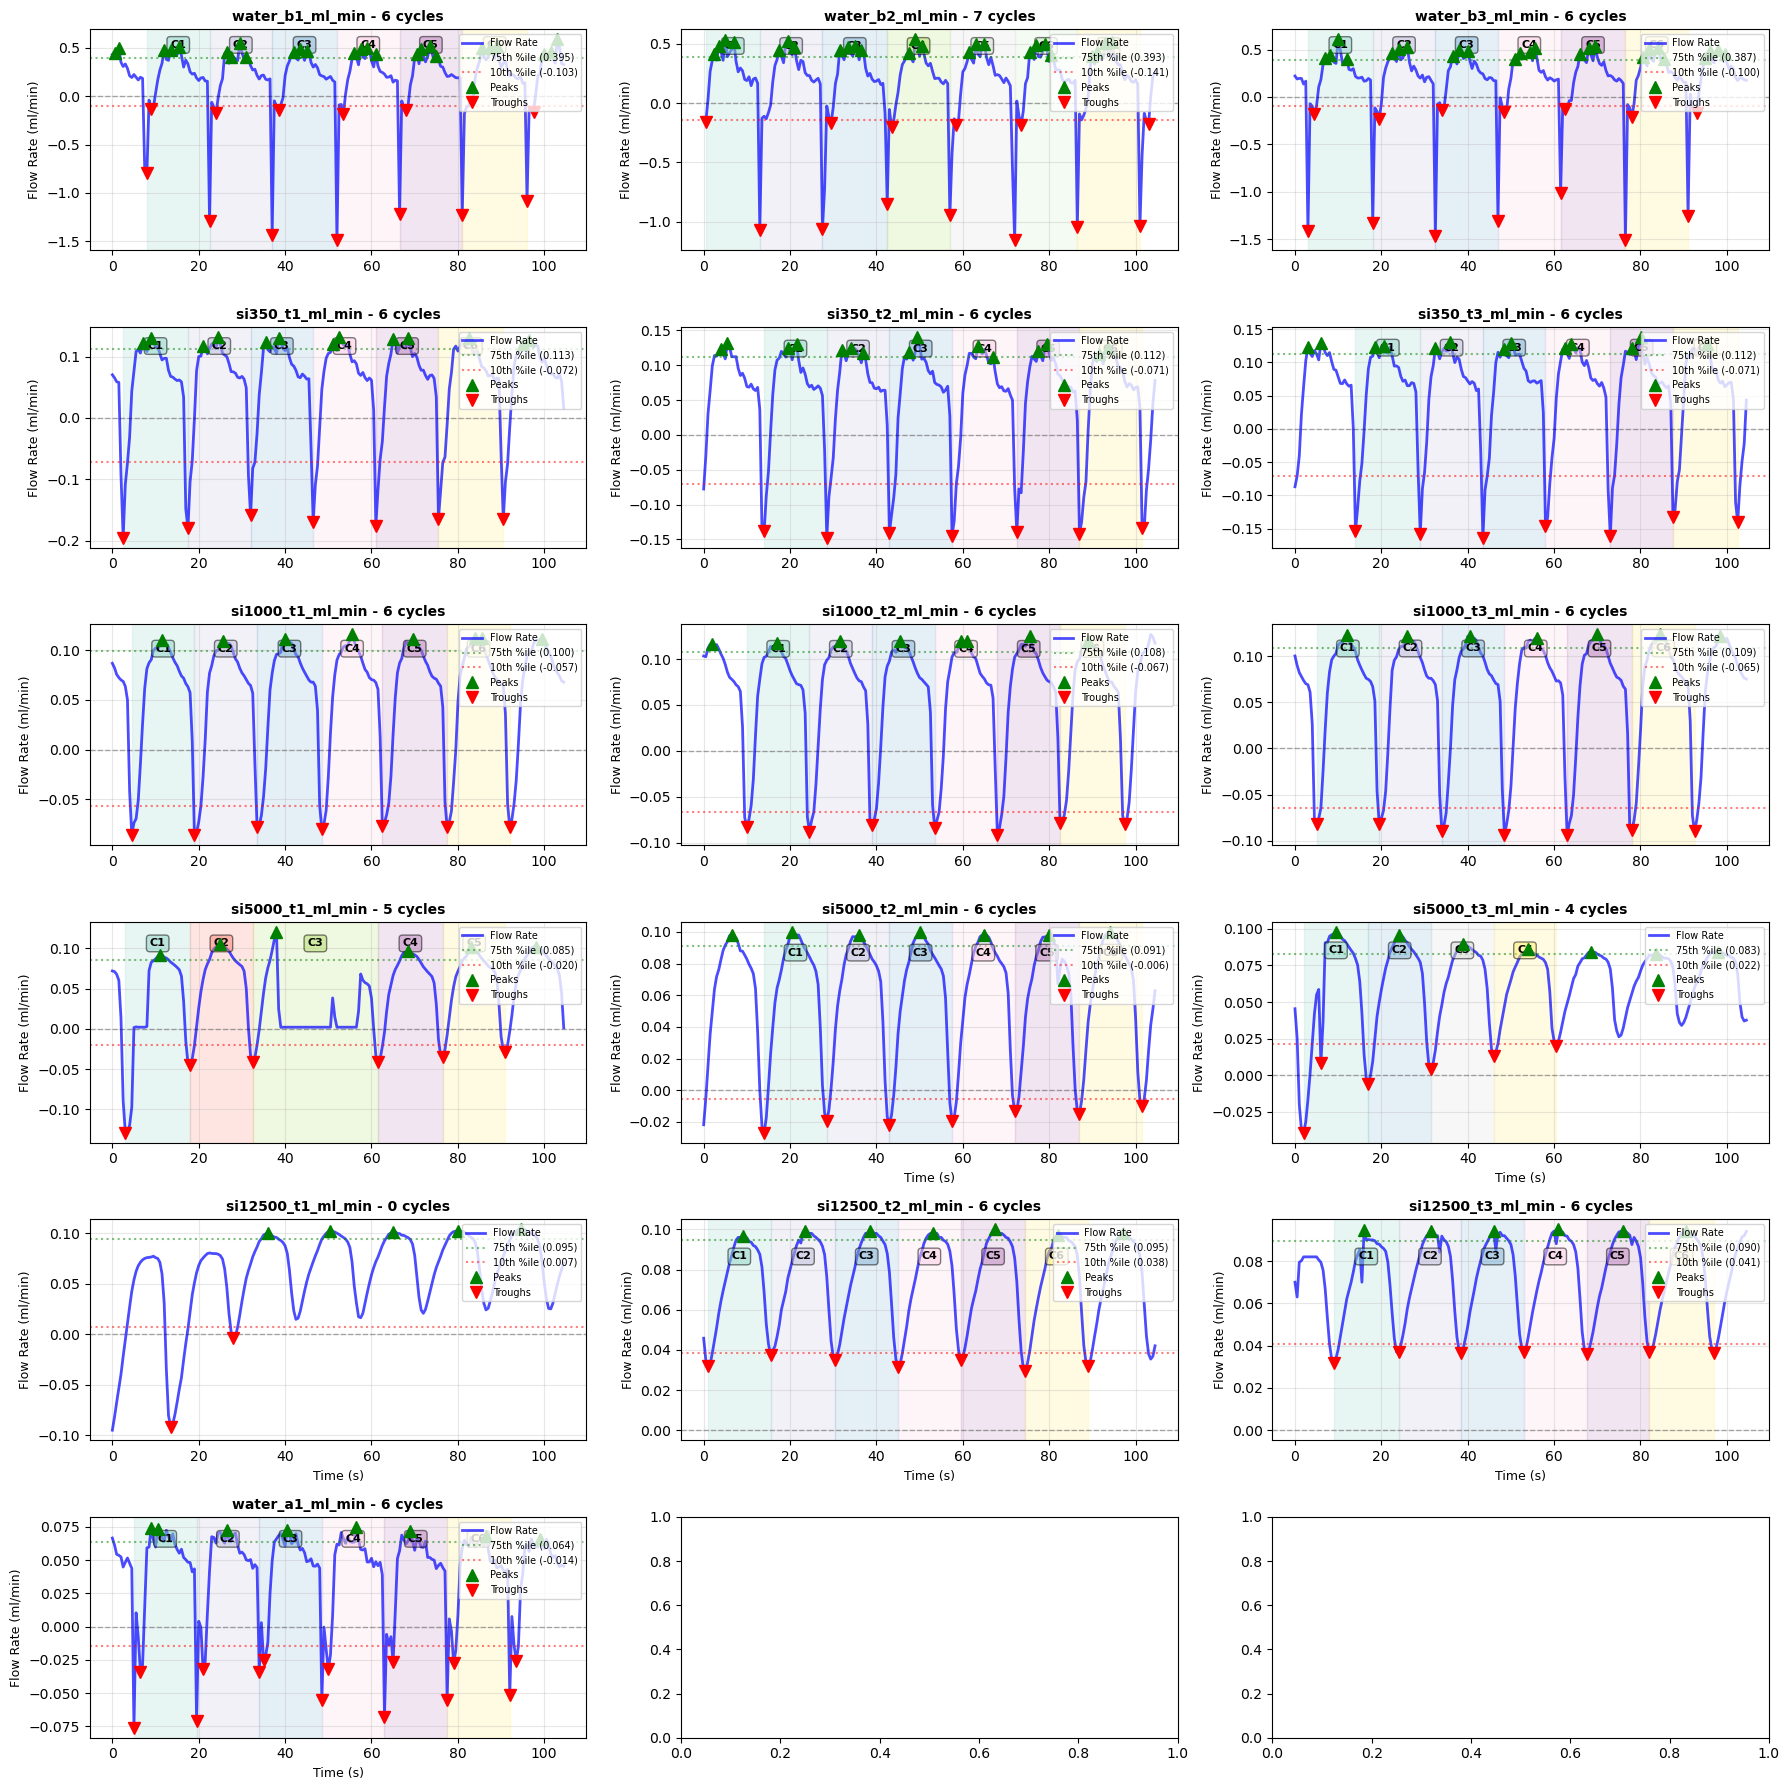


SUMMARY TABLE


,Column,Cycles,Avg Duration (s),Std Dev (s),Min (s),Max (s)
0,water_b1_ml_min,6,14.67,0.23,14.50,15.00
1,water_b2_ml_min,7,14.36,0.79,12.50,15.00
2,water_b3_ml_min,6,14.67,0.24,14.50,15.01
3,si350_t1_ml_min,6,14.67,0.24,14.50,15.01
4,si350_t2_ml_min,6,14.59,0.19,14.50,15.00
5,si350_t3_ml_min,6,14.75,0.25,14.50,15.00
6,si1000_t1_ml_min,6,14.59,0.35,14.00,15.01
7,si1000_t2_ml_min,6,14.59,0.18,14.50,15.00
8,si1000_t3_ml_min,6,14.59,0.19,14.50,15.01
9,si5000_t1_ml_min,5,17.60,5.70,14.50,29.00


In [25]:
# Analyze each flow column
all_results = {}

for col in flow_columns:
    flow = df[col].values
    
    print("=" * 80)
    print(f"ANALYZING: {col}")
    print("=" * 80)
    
    # Remove NaN for peak detection
    valid_indices = ~np.isnan(flow)
    if np.sum(valid_indices) < 5:
        print("  Insufficient valid data points\n")
        continue
    
    # Find peaks (local maxima)
    peaks, _ = find_peaks(flow[valid_indices], prominence=0.01)
    # Map back to original indices
    peaks = np.where(valid_indices)[0][peaks]
    
    # Find troughs (local minima) by inverting the signal
    troughs, _ = find_peaks(-flow[valid_indices], prominence=0.01)
    troughs = np.where(valid_indices)[0][troughs]
    
    print(f"\nInitial detection:")
    print(f"  Raw peaks found: {len(peaks)}")
    print(f"  Raw troughs found: {len(troughs)}")
    
    # Filter peaks and troughs based on percentile and distance
    peaks, troughs, peak_thresh, trough_thresh = filter_peaks_troughs(time, flow, peaks, troughs, min_distance=0.0)
    
    print(f"\nAfter filtering (75th/10th percentile + min distance 2.0s):")
    print(f"  Peak threshold (75th percentile): {peak_thresh:.4f}")
    print(f"  Trough threshold (10th percentile): {trough_thresh:.4f}")
    print(f"  Valid peaks: {len(peaks)}")
    if len(peaks) > 0:
        print(f"    Times: {time[peaks]}")
        print(f"    Values: {np.round(flow[peaks], 4)}")
    
    print(f"  Valid troughs: {len(troughs)}")
    if len(troughs) > 0:
        print(f"    Times: {time[troughs]}")
        print(f"    Values: {np.round(flow[troughs], 4)}")
    
    # Detect cycles
    cycles = detect_cycles(time, flow, peaks, troughs)
    
    print(f"\n{'─' * 80}")
    print(f"CYCLES DETECTED: {len(cycles)}")
    print(f"{'─' * 80}")
    
    if cycles:
        for idx, cycle in enumerate(cycles, 1):
            print(f"Cycle {idx}:")
            print(f"  Start: {cycle['start_time']:.1f} s  |  End: {cycle['end_time']:.1f} s  |  Duration: {cycle['duration']:.2f} s")
        
        durations = [c['duration'] for c in cycles]
        print(f"\nSummary:")
        print(f"  Avg duration: {np.mean(durations):.2f} s ± {np.std(durations):.2f} s")
        print(f"  Range: [{np.min(durations):.2f}, {np.max(durations):.2f}] s")
    else:
        print("  No cycles detected")
    
    print()
    
    all_results[col] = {
        'flow': flow,
        'peaks': peaks,
        'troughs': troughs,
        'cycles': cycles,
        'peak_thresh': peak_thresh,
        'trough_thresh': trough_thresh
    }# Create visualizations for flow columns
fig, axes = plt.subplots(6, 3, figsize=(18, 18))

# Flatten axes for easier iteration
axes_flat = axes.flatten()

for idx, col in enumerate(flow_columns):
    if col not in all_results:
        continue
    ax = axes_flat[idx]
    result = all_results[col]
    flow = result['flow']
    peaks = result['peaks']
    troughs = result['troughs']
    cycles = result['cycles']
    peak_thresh = result['peak_thresh']
    trough_thresh = result['trough_thresh']
    
    # Plot flow rate
    ax.plot(time, flow, 'b-', linewidth=2, alpha=0.7, label='Flow Rate')
    
    # Plot threshold lines
    if not np.isnan(peak_thresh):
        ax.axhline(y=peak_thresh, color='green', linestyle=':', alpha=0.5, linewidth=1.5, label=f'75th %ile ({peak_thresh:.3f})')
    if not np.isnan(trough_thresh):
        ax.axhline(y=trough_thresh, color='red', linestyle=':', alpha=0.5, linewidth=1.5, label=f'10th %ile ({trough_thresh:.3f})')
    
    # Mark peaks and troughs
    if len(peaks) > 0:
        ax.plot(time[peaks], flow[peaks], 'g^', markersize=8, label='Peaks', zorder=5)
    if len(troughs) > 0:
        ax.plot(time[troughs], flow[troughs], 'rv', markersize=8, label='Troughs', zorder=5)
    
    # Highlight cycles
    colors = plt.cm.Set3(np.linspace(0, 1, max(len(cycles), 1)))
    for cycle_idx, cycle in enumerate(cycles):
        ax.axvspan(cycle['start_time'], cycle['end_time'], alpha=0.2, color=colors[cycle_idx])
        mid_time = (cycle['start_time'] + cycle['end_time']) / 2
        y_pos = np.nanmax(flow) * 0.85 if not np.isnan(np.nanmax(flow)) else 0.1
        ax.text(mid_time, y_pos, f"C{cycle_idx+1}", 
                ha='center', fontsize=8, fontweight='bold', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[cycle_idx], alpha=0.5))
    
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
    ax.set_ylabel('Flow Rate (ml/min)', fontsize=9)
    ax.set_title(f'{col} - {len(cycles)} cycles', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.3)
    
    # Set x-label only for bottom row
    if idx >= 10:
        ax.set_xlabel('Time (s)', fontsize=9)
plt.tight_layout()
plt.show()

# Create summary table
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
summary_data = []
for col in all_results.keys():
    cycles = all_results[col]['cycles']
    if cycles:
        durations = [c['duration'] for c in cycles]
        summary_data.append({
            'Column': col,
            'Cycles': len(cycles),
            'Avg Duration (s)': f"{np.mean(durations):.2f}",
            'Std Dev (s)': f"{np.std(durations):.2f}",
            'Min (s)': f"{np.min(durations):.2f}",
            'Max (s)': f"{np.max(durations):.2f}"
        })
    else:
        summary_data.append({
            'Column': col,
            'Cycles': 0,
            'Avg Duration (s)': 'N/A',
            'Std Dev (s)': 'N/A',
            'Min (s)': 'N/A',
            'Max (s)': 'N/A'
        })

summary_df = pd.DataFrame(summary_data)
summary_df

In [28]:
def analyze_cycle_segments(time, flow, cycle_start_idx, cycle_end_idx):
    """
    Analyze a single cycle and fit 3 linear segments:
    1. Sharp increasing (first line) - from cycle start to first point that is positive AND in top 75% percentile
    2. Gradual decreasing (second line)
    3. Sharp decreasing (third line)
    """
    # Extract cycle data
    cycle_time = time[cycle_start_idx:cycle_end_idx+1]
    cycle_flow = flow[cycle_start_idx:cycle_end_idx+1]
    
    # Remove NaN values
    valid_mask = ~np.isnan(cycle_flow)
    cycle_time = cycle_time[valid_mask]
    cycle_flow = cycle_flow[valid_mask]
    
    if len(cycle_time) < 5:
        return None
    
    # Calculate 75th percentile for the cycle
    flow_75 = np.percentile(cycle_flow, 40)
    
    # Find ALL peaks and troughs within this cycle (no filtering)
    all_peaks, _ = find_peaks(cycle_flow, prominence=0.001)
    all_troughs, _ = find_peaks(-cycle_flow, prominence=0.001)
    
    # Combine all critical points
    critical_points = []
    critical_points.append((0, cycle_time[0], cycle_flow[0], 'start'))  # Start point
    
    for p in all_peaks:
        critical_points.append((p, cycle_time[p], cycle_flow[p], 'peak'))
    for t in all_troughs:
        critical_points.append((t, cycle_time[t], cycle_flow[t], 'trough'))
    
    critical_points.append((len(cycle_time)-1, cycle_time[-1], cycle_flow[-1], 'end'))  # End point
    
    # --- Detect a 'drop' critical point (start of sharp fall) ---
    # Compute local slopes (dy/dt)
    dt = np.diff(cycle_time)
    dy = np.diff(cycle_flow)
    slope = dy / np.maximum(dt, 1e-12)

    # Optional light smoothing of slope (moving average) to reduce noise
    win = 3  # set to 1 to disable smoothing
    if len(slope) >= win and win > 1:
        kernel = np.ones(win) / win
        slope_s = np.convolve(slope, kernel, mode='same')
    else:
        slope_s = slope

    # Heuristic: search for the drop *after* the local maximum of the cycle
    after_idx = int(np.argmax(cycle_flow))

    # Build a data-driven threshold for "strongly negative" slope
    neg = slope_s[slope_s < 0]
    # Use 75th percentile of |negative slopes| as a magnitude threshold
    thr_mag = np.percentile(-neg, 75) if neg.size > 0 else 0.0
    min_run = 2  # require at least this many consecutive steps below -thr_mag

    drop_k = None
    run = 0
    for k_idx in range(max(after_idx, 0), len(slope_s)):
        if slope_s[k_idx] <= -thr_mag:
            run += 1
            if run >= min_run:
                # choose the *start* of the sustained run
                drop_k = k_idx - min_run + 1
                break
        else:
            run = 0

    # Fallback: if no sustained run, use the steepest negative slope anywhere
    if drop_k is None:
        drop_k = int(np.argmin(slope_s)) if slope_s.size > 0 else None

    # Map slope index (between k and k+1) to a point index (use k+1)
    if drop_k is not None:
        cp_idx = drop_k + 1
        # keep within bounds and avoid duplicating the start/end indices
        cp_idx = int(np.clip(cp_idx, 1, len(cycle_time) - 2))
        existing_idxs = {cp[0] for cp in critical_points}
        if cp_idx not in existing_idxs:
            critical_points.append((cp_idx, cycle_time[cp_idx], cycle_flow[cp_idx], 'drop'))
    # --- end 'drop' detection ---


    # Sort by index
    critical_points.sort(key=lambda x: x[0])
    
    # Find Line 1: From cycle start to first point that is BOTH positive AND >= 75th percentile
    line1_end_idx = None
    for i, (idx, t, f, ptype) in enumerate(critical_points):
        if i == 0:  # Skip start point itself
            continue
        if f > 0 and f >= flow_75:
            line1_end_idx = idx
            line1_end_time = t
            line1_end_flow = f
            break
    
    # If no point satisfies both conditions, use the maximum point in the cycle
    if line1_end_idx is None:
        max_idx = np.argmax(cycle_flow)
        line1_end_idx = max_idx
        line1_end_time = cycle_time[max_idx]
        line1_end_flow = cycle_flow[max_idx]
    
    # Line 1: from start to the identified end point
    line1 = {
        'start_time': cycle_time[0],
        'end_time': line1_end_time,
        'start_flow': cycle_flow[0],
        'end_flow': line1_end_flow,
        'slope': (line1_end_flow - cycle_flow[0]) / (line1_end_time - cycle_time[0]) if line1_end_time != cycle_time[0] else 0,
        'start_idx': 0,
        'end_idx': line1_end_idx
    }
    
    # Calculate slopes between consecutive critical points (after Line 1 end)
    slopes = []
    for i in range(len(critical_points) - 1):
        idx1, t1, f1, _ = critical_points[i]
        idx2, t2, f2, _ = critical_points[i+1]
        
        # Only consider points after Line 1 end
        if idx1 < line1_end_idx:
            continue
        
        if t2 != t1:
            slope = (f2 - f1) / (t2 - t1)
            slopes.append({
                'segment': i,
                'start_idx': idx1,
                'end_idx': idx2,
                'start_time': t1,
                'end_time': t2,
                'start_flow': f1,
                'end_flow': f2,
                'slope': slope,
                'duration': t2 - t1
            })
    
    if len(slopes) < 2:
        # Not enough segments, create simple lines
        mid_idx = line1_end_idx + (len(cycle_time) - line1_end_idx) // 2
        
        line2 = {
            'start_time': line1_end_time,
            'end_time': cycle_time[mid_idx],
            'start_flow': line1_end_flow,
            'end_flow': cycle_flow[mid_idx],
            'slope': (cycle_flow[mid_idx] - line1_end_flow) / (cycle_time[mid_idx] - line1_end_time) if cycle_time[mid_idx] != line1_end_time else 0,
            'intercept': 0
        }
        
        line3 = {
            'segment': 0,
            'start_idx': mid_idx,
            'end_idx': len(cycle_time) - 1,
            'start_time': cycle_time[mid_idx],
            'end_time': cycle_time[-1],
            'start_flow': cycle_flow[mid_idx],
            'end_flow': cycle_flow[-1],
            'slope': (cycle_flow[-1] - cycle_flow[mid_idx]) / (cycle_time[-1] - cycle_time[mid_idx]) if cycle_time[-1] != cycle_time[mid_idx] else 0,
            'duration': cycle_time[-1] - cycle_time[mid_idx]
        }
        
        return {
            'line1': line1,
            'line2': line2,
            'line3': line3,
            'all_slopes': [],
            'critical_points': critical_points
        }
    
    # Find Line 3: steepest negative slope (sharp decrease at the end)
    negative_slopes = [s for s in slopes if s['slope'] < 0]
    
    if len(negative_slopes) > 0:
        line3 = min(negative_slopes, key=lambda x: x['slope'])
        line3_start_idx = line3['start_idx']
    else:
        line3 = slopes[-1]
        line3_start_idx = line3['start_idx']
    
    # Line 2: everything between line1 end and line3 start
    middle_segments = [s for s in slopes if s['end_idx'] <= line3_start_idx]
    
    if len(middle_segments) > 0:
        # Fit a single line through all middle points
        middle_time = []
        middle_flow = []
        for seg in middle_segments:
            start_idx = seg['start_idx']
            end_idx = seg['end_idx']
            middle_time.extend(cycle_time[start_idx:end_idx+1])
            middle_flow.extend(cycle_flow[start_idx:end_idx+1])
        
        if len(middle_time) >= 2:
            slope2, intercept2, _, _, _ = linregress(middle_time, middle_flow)
            line2 = {
                'start_time': line1_end_time,
                'end_time': cycle_time[line3_start_idx],
                'start_flow': slope2 * line1_end_time + intercept2,
                'end_flow': slope2 * cycle_time[line3_start_idx] + intercept2,
                'slope': slope2,
                'intercept': intercept2
            }
        else:
            # If only one point, create a simple connection
            line2 = {
                'start_time': line1_end_time,
                'end_time': cycle_time[line3_start_idx],
                'start_flow': line1_end_flow,
                'end_flow': cycle_flow[line3_start_idx],
                'slope': (cycle_flow[line3_start_idx] - line1_end_flow) / 
                        (cycle_time[line3_start_idx] - line1_end_time) if cycle_time[line3_start_idx] != line1_end_time else 0,
                'intercept': 0
            }
    else:
        # No middle segment, connect directly
        line2 = {
            'start_time': line1_end_time,
            'end_time': cycle_time[line3_start_idx],
            'start_flow': line1_end_flow,
            'end_flow': cycle_flow[line3_start_idx],
            'slope': (cycle_flow[line3_start_idx] - line1_end_flow) / 
                    (cycle_time[line3_start_idx] - line1_end_time) if cycle_time[line3_start_idx] != line1_end_time else 0,
            'intercept': 0
        }
    
    return {
        'line1': line1,  # Sharp increase
        'line2': line2,  # Gradual decrease
        'line3': line3,  # Sharp decrease
        'all_slopes': slopes,
        'critical_points': critical_points
    }

# Analyze each flow column
all_cycle_segments = {}

for col in flow_columns:
    if col not in df.columns:
        continue
    
    flow = df[col].values
    
    if np.all(np.isnan(flow)):
        continue
    
    print("=" * 80)
    print(f"ANALYZING: {col}")
    print("=" * 80)
    
    # Remove NaN for peak detection
    valid_indices = ~np.isnan(flow)
    if np.sum(valid_indices) < 5:
        continue
    
    # Detect cycles (using filtered peaks/troughs)
    peaks, _ = find_peaks(flow[valid_indices], prominence=0.01)
    peaks = np.where(valid_indices)[0][peaks]
    
    troughs, _ = find_peaks(-flow[valid_indices], prominence=0.01)
    troughs = np.where(valid_indices)[0][troughs]
    
    peaks_filt, troughs_filt, _, _ = filter_peaks_troughs(time, flow, peaks, troughs, min_distance=2.0)
    cycles = detect_cycles(time, flow, peaks_filt, troughs_filt)
    
    print(f"\nDetected {len(cycles)} cycles")
    
    # Analyze each cycle
    cycle_segments = []
    for cycle_num, cycle in enumerate(cycles, 1):
        print(f"\nCycle {cycle_num} (t={cycle['start_time']:.1f}s to {cycle['end_time']:.1f}s):")
        
        segments = analyze_cycle_segments(time, flow, cycle['start_idx'], cycle['end_idx'])
        
        if segments:
            print(f"  Line 1 criteria: Start at cycle beginning, end at first point that is positive AND >= 75th percentile")
            print(f"  Line 1 (Sharp Increase): slope = {segments['line1']['slope']:.4f} ml/min/s")
            print(f"    Time: {segments['line1']['start_time']:.2f}s to {segments['line1']['end_time']:.2f}s")
            print(f"    Flow: {segments['line1']['start_flow']:.4f} to {segments['line1']['end_flow']:.4f} ml/min")
            print(f"  Line 2 (Gradual Change): slope = {segments['line2']['slope']:.4f} ml/min/s")
            print(f"    Time: {segments['line2']['start_time']:.2f}s to {segments['line2']['end_time']:.2f}s")
            print(f"    Flow: {segments['line2']['start_flow']:.4f} to {segments['line2']['end_flow']:.4f} ml/min")
            print(f"  Line 3 (Sharp Decrease): slope = {segments['line3']['slope']:.4f} ml/min/s")
            print(f"    Time: {segments['line3']['start_time']:.2f}s to {segments['line3']['end_time']:.2f}s")
            print(f"    Flow: {segments['line3']['start_flow']:.4f} to {segments['line3']['end_flow']:.4f} ml/min")
            
            cycle_segments.append({
                'cycle_num': cycle_num,
                'cycle': cycle,
                'segments': segments
            })
    
    all_cycle_segments[col] = cycle_segments

ANALYZING: water_b1_ml_min

Detected 6 cycles

Cycle 1 (t=8.0s to 22.5s):
  Line 1 criteria: Start at cycle beginning, end at first point that is positive AND >= 75th percentile
  Line 1 (Sharp Increase): slope = 0.3189 ml/min/s
    Time: 8.01s to 12.01s
    Flow: -0.7944 to 0.4820 ml/min
  Line 2 (Gradual Change): slope = -0.0361 ml/min/s
    Time: 12.01s to 22.01s
    Flow: 0.5040 to 0.1424 ml/min
  Line 3 (Sharp Decrease): slope = -2.8904 ml/min/s
    Time: 22.01s to 22.51s
    Flow: 0.1566 to -1.2886 ml/min

Cycle 2 (t=22.5s to 37.0s):
  Line 1 criteria: Start at cycle beginning, end at first point that is positive AND >= 75th percentile
  Line 1 (Sharp Increase): slope = 0.4377 ml/min/s
    Time: 22.51s to 26.51s
    Flow: -1.2886 to 0.4624 ml/min
  Line 2 (Gradual Change): slope = -0.0301 ml/min/s
    Time: 26.51s to 36.51s
    Flow: 0.4734 to 0.1721 ml/min
  Line 3 (Sharp Decrease): slope = -3.2284 ml/min/s
    Time: 36.51s to 37.01s
    Flow: 0.1804 to -1.4338 ml/min

Cycle 3 (


Segmentation plot saved as 'cycle_segmentation_analysis.png'


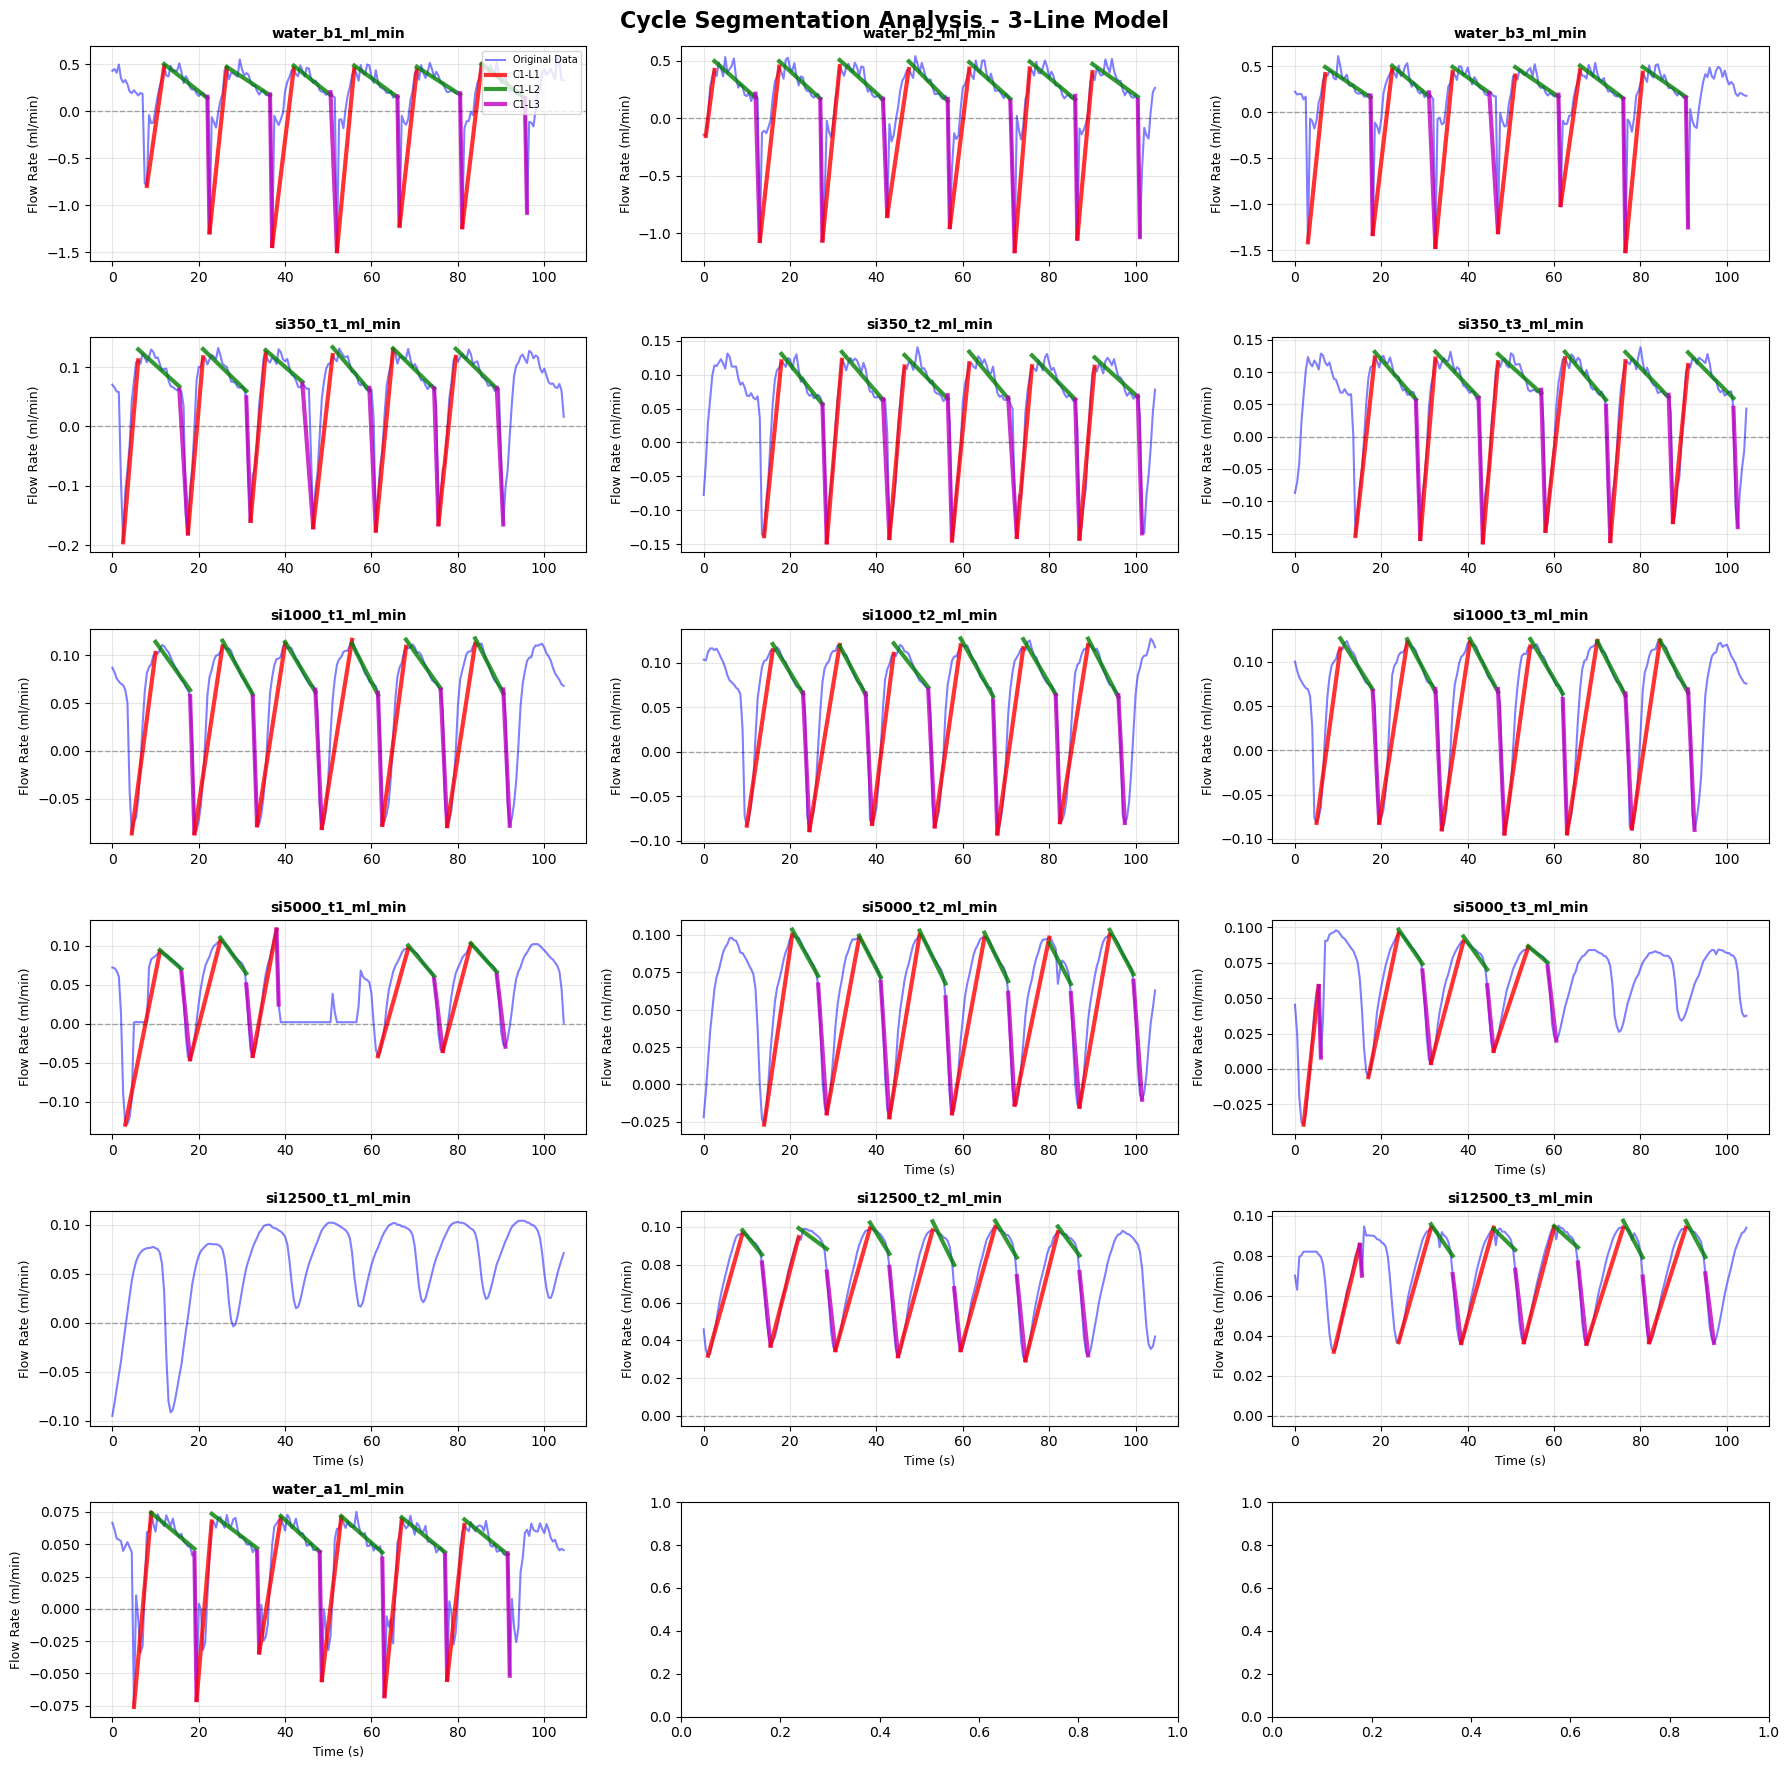

In [29]:
# Visualize cycles with 3-line segments
fig, axes = plt.subplots(6, 3, figsize=(18, 18))
fig.suptitle('Cycle Segmentation Analysis - 3-Line Model', fontsize=16, fontweight='bold')

axes_flat = axes.flatten()

for idx, col in enumerate(flow_columns):
    if col not in all_cycle_segments:
        continue
    
    ax = axes_flat[idx]
    flow = df[col].values
    
    # Plot original data
    ax.plot(time, flow, 'b-', linewidth=1.5, alpha=0.5, label='Original Data')
    
    # Plot each cycle's segments
    cycle_data = all_cycle_segments[col]
    colors = plt.cm.tab10(np.linspace(0, 1, len(cycle_data)))
    
    for i, cycle_info in enumerate(cycle_data):
        segments = cycle_info['segments']
        color = colors[i]
        
        # Plot Line 1 (Sharp increase)
        line1 = segments['line1']
        ax.plot([line1['start_time'], line1['end_time']], 
                [line1['start_flow'], line1['end_flow']], 
                'r-', linewidth=3, alpha=0.8, label=f"C{i+1}-L1" if i == 0 else "")
        
        # Plot Line 2 (Gradual change)
        line2 = segments['line2']
        ax.plot([line2['start_time'], line2['end_time']], 
                [line2['start_flow'], line2['end_flow']], 
                'g-', linewidth=3, alpha=0.8, label=f"C{i+1}-L2" if i == 0 else "")
        
        # Plot Line 3 (Sharp decrease)
        line3 = segments['line3']
        ax.plot([line3['start_time'], line3['end_time']], 
                [line3['start_flow'], line3['end_flow']], 
                'm-', linewidth=3, alpha=0.8, label=f"C{i+1}-L3" if i == 0 else "")
    
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
    ax.set_ylabel('Flow Rate (ml/min)', fontsize=9)
    ax.set_title(f'{col}', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    if idx >= 10:
        ax.set_xlabel('Time (s)', fontsize=9)
    
    if idx == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('cycle_segmentation_analysis.png', dpi=150, bbox_inches='tight')
print("\n" + "=" * 80)
print("Segmentation plot saved as 'cycle_segmentation_analysis.png'")
print("=" * 80)
plt.show()

# Export segment data
segment_export = []
for col in all_cycle_segments.keys():
    for cycle_info in all_cycle_segments[col]:
        cycle_num = cycle_info['cycle_num']
        segments = cycle_info['segments']
        
        segment_export.append({
            'Column': col,
            'Cycle': cycle_num,
            'Line1_Slope': segments['line1']['slope'],
            'Line1_Start_Time': segments['line1']['start_time'],
            'Line1_End_Time': segments['line1']['end_time'],
            'Line2_Slope': segments['line2']['slope'],
            'Line2_Start_Time': segments['line2']['start_time'],
            'Line2_End_Time': segments['line2']['end_time'],
            'Line3_Slope': segments['line3']['slope'],
            'Line3_Start_Time': segments['line3']['start_time'],
            'Line3_End_Time': segments['line3']['end_time']
        })

segment_df = pd.DataFrame(segment_export)

In [32]:
viscosity_map = {
    'water_b1_ml_min'  : 1,
    'water_b2_ml_min'  : 1,
    'water_b3_ml_min' : 1,
    'si350_t1_ml_min' : 350,
    'si350_t2_ml_min' : 350,
    'si350_t3_ml_min' : 350,
    'si1000_t1_ml_min' : 1000,
    'si1000_t2_ml_min' : 1000,
    'si1000_t3_ml_min' : 1000,
    'si5000_t1_ml_min' : 5000,
    'si5000_t2_ml_min' : 5000,
    'si5000_t3_ml_min' : 5000,
    'si12500_t1_ml_min' : 12500,
    'si12500_t2_ml_min' : 12500,
    'si12500_t3_ml_min' : 12500
}

segment_df['Viscosity_mPa_s'] = segment_df['Column'].map(viscosity_map).astype(float)

if segment_export:
    segment_df.to_csv('cycle_segments.csv', index=False)
    print("\nSegment data exported to 'cycle_segments.csv'")
    print("=" * 80)

print(segment_df.shape)
segment_df[:60]


Segment data exported to 'cycle_segments.csv'
(88, 12)


,Column,Cycle,Line1_Slope,Line1_Start_Time,Line1_End_Time,Line2_Slope,Line2_Start_Time,Line2_End_Time,Line3_Slope,Line3_Start_Time,Line3_End_Time,Viscosity_mPa_s
0,water_b1_ml_min,1,0.318941,8.007,12.009,-0.036140,12.009,22.013,-2.890400,22.013,22.513,1.0
1,water_b1_ml_min,2,0.437750,22.513,26.513,-0.030131,26.513,36.514,-3.228400,36.514,37.014,1.0
2,water_b1_ml_min,3,0.378040,37.014,42.014,-0.036641,42.014,50.514,-1.129200,50.514,52.014,1.0
3,water_b1_ml_min,4,0.485250,52.014,56.014,-0.033489,56.014,66.015,-2.754000,66.015,66.515,1.0
4,water_b1_ml_min,5,0.414539,66.515,70.518,-0.029579,70.518,80.527,-2.852000,80.527,81.027,1.0
5,water_b1_ml_min,6,0.385244,81.027,85.527,-0.036603,85.527,95.527,-2.444800,95.527,96.027,1.0
6,water_b2_ml_min,1,0.286700,0.507,2.507,-0.033206,2.507,12.009,-1.279600,12.009,13.009,1.0
7,water_b2_ml_min,2,0.336622,13.009,17.509,-0.034176,17.509,27.013,-2.453200,27.013,27.513,1.0
8,water_b2_ml_min,3,0.378705,27.513,31.514,-0.033889,31.514,41.514,-1.017600,41.514,42.514,1.0
9,water_b2_ml_min,4,0.255280,42.514,47.514,-0.038289,47.514,56.514,-2.225200,56.514,57.014,1.0


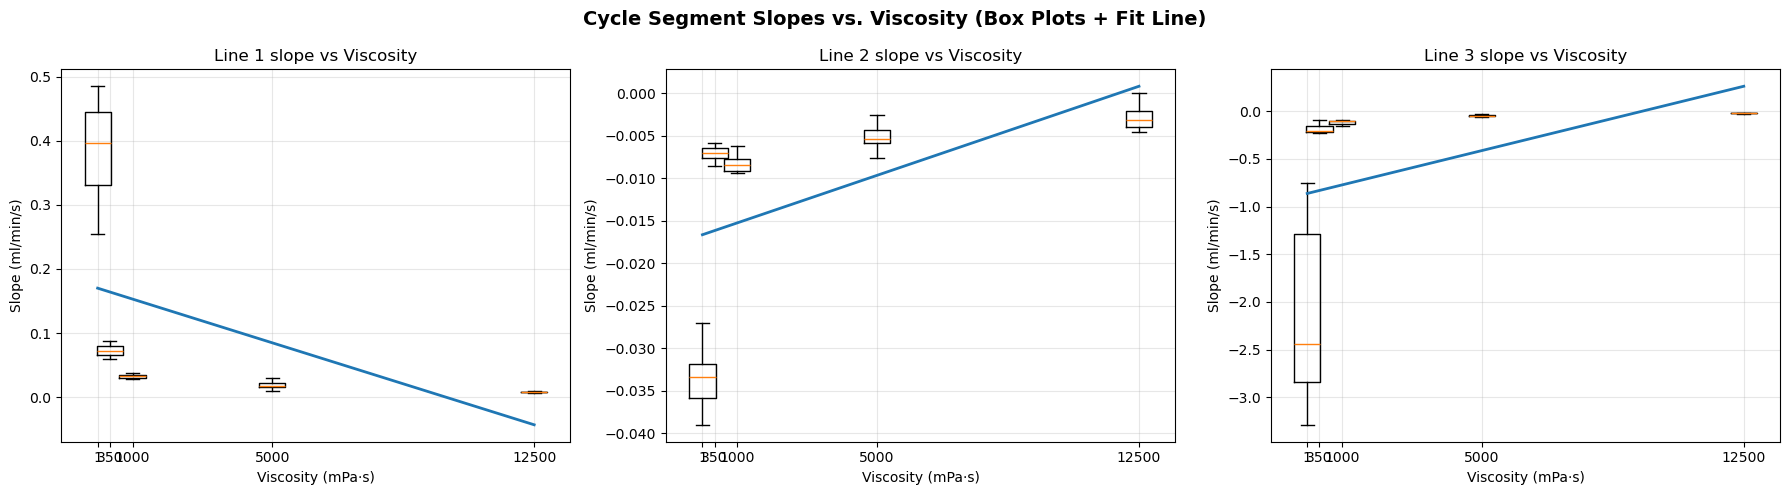

In [41]:
def plot_panel_box(ax, x, y, title,
                   xlab='Viscosity (mPa·s)', ylab='Slope (ml/min/s)',
                   try_fit=True, logx=False, showfliers=False):
    # Drop NaNs
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = np.asarray(x)[mask].astype(float)
    y = np.asarray(y)[mask].astype(float)
    if x.size == 0:
        ax.set_title(title); ax.set_xlabel(xlab); ax.set_ylabel(ylab)
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        return

    # Group by viscosity value (assumes viscosities like 50, 100, 200, ...)
    # If your viscosities might be non-integers, you can round: uniq = np.unique(np.round(x, 3))
    uniq = np.unique(x)
    data = [y[x == v] for v in uniq if np.sum(x == v) > 0]
    pos  = [v for v in uniq if np.sum(x == v) > 0]

    # Box plot at numeric positions corresponding to viscosity values
    bp = ax.boxplot(
        data, positions=pos, widths=0.06*(max(pos)-min(pos)) if len(pos) > 1 else 0.5,
        showfliers=showfliers
    )

    # Optional linear fit across all raw points (x, y)
    if try_fit and x.size >= 2 and np.unique(x).size >= 2:
        try:
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(np.min(x), np.max(x), 200)
            ax.plot(xs, m*xs + b, linewidth=2)
        except Exception:
            pass

    # Axes formatting - always use linear scale
    ax.set_xticks(pos)
    # Render integer-like ticks without decimals
    ax.set_xticklabels([str(int(p)) if float(p).is_integer() else f"{p:g}" for p in pos], rotation=0)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)

# --- Data arrays ---
visc = segment_df['Viscosity_mPa_s'].astype(float).values
l1   = segment_df['Line1_Slope'].astype(float).values
l2   = segment_df['Line2_Slope'].astype(float).values
l3   = segment_df['Line3_Slope'].astype(float).values

# --- Figure with 3 panels in a row ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_panel_box(axes[0], visc, l1, 'Line 1 slope vs Viscosity')
plot_panel_box(axes[1], visc, l2, 'Line 2 slope vs Viscosity')
plot_panel_box(axes[2], visc, l3, 'Line 3 slope vs Viscosity')

fig.suptitle('Cycle Segment Slopes vs. Viscosity (Box Plots + Fit Line)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()